# Train — fox policy (behavioural cloning, no memory)

Clone the **fox** RuleBrain into a small memoryless network:

```
grids (C,K,K) ─CNN─┐
                   ├─▶ trunk (MLP) ─▶ heading mean (2)  ─ MSE  ─▶ teacher heading
scalars (10) ─MLP──┘                 gate logits  (3)  ─ BCE  ─▶ eat / drink / repro
                                     speed logit  (1)  ─ BCE  ─▶ speed throttle
```

Same CNN front-end as the deployed brain (`sim/neural_brain.py`), but the LSTM is replaced
by a feed-forward trunk and the critic is dropped — this is supervised imitation, not RL.
We **hold out one whole world** for validation, so the reported metrics measure
generalization to a map the network never trained on.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
for _c in (_cwd, _cwd / "notebooks" / "imitation_learning"):
    if (_c / "common.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import torch
import common as C
from config import SHEEP, FOX, SPECIES_NAMES

SID = FOX
device = "cuda" if torch.cuda.is_available() else "cpu"
print("species:", SPECIES_NAMES[SID], "| device:", device,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

species: fox | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## Load the dataset

Grids stay **float16** in CPU RAM; each minibatch is sliced and moved to the GPU as float32,
so the whole dataset never has to fit in VRAM at once.

In [2]:
d = C.load_dataset(SID)
print("rows:", d['grids'].shape[0], "| grids:", d['grids'].shape[1:],
      "| worlds:", np.bincount(d['world']))
VAL_WORLD = int(d['world'].max())        # held-out validation world (last collected)

rows: 90000 | grids: (4, 57, 57) | worlds: [3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000
 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000 3000
 3000 3000]


## Train

GPU-batched behavioural cloning. Watch `val cos` (heading cosine vs the teacher, →1 is
perfect) and the per-gate accuracies climb on the held-out world.

In [3]:
model, history = C.train_policy(SID, d, device=device, epochs=25,
                               batch_size=512, lr=1e-3, val_world=VAL_WORLD)

  gate +rates [0.07 0.21 0.45] speed +rate 0.44 -> pos_weight gates [12.7  3.7  1.2] speed 1.3
  [fox  1/25] loss=2.2816 (head=0.9656 gate=0.9345 speed=0.7630) | val cos=0.166 eat=0.59 drink=1.00 repro=0.67 speed=0.71
  [fox  2/25] loss=1.9562 (head=0.8632 gate=0.7570 speed=0.6719) | val cos=0.326 eat=0.51 drink=0.98 repro=0.77 speed=0.75
  [fox  3/25] loss=1.5415 (head=0.7171 gate=0.5978 speed=0.4532) | val cos=0.514 eat=0.79 drink=0.95 repro=0.81 speed=0.87
  [fox  4/25] loss=1.2989 (head=0.6398 gate=0.4872 speed=0.3437) | val cos=0.549 eat=0.76 drink=0.99 repro=0.81 speed=0.87
  [fox  5/25] loss=1.1437 (head=0.5867 gate=0.4115 speed=0.2910) | val cos=0.542 eat=0.78 drink=0.99 repro=0.82 speed=0.86
  [fox  6/25] loss=1.0397 (head=0.5468 gate=0.3633 speed=0.2591) | val cos=0.496 eat=0.82 drink=1.00 repro=0.80 speed=0.84
  [fox  7/25] loss=0.9599 (head=0.5190 gate=0.3230 speed=0.2359) | val cos=0.508 eat=0.79 drink=1.00 repro=0.80 speed=0.85
  [fox  8/25] loss=0.8956 (head=0.4942 gate=

## Results

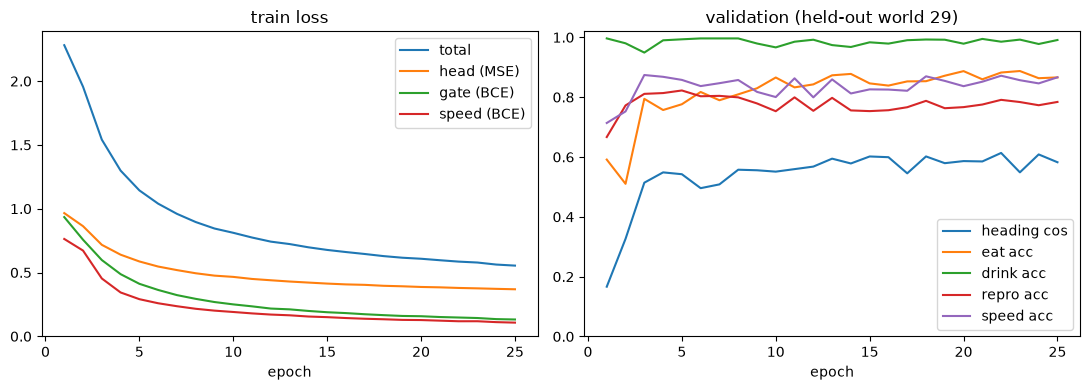

{'heading_cos': 0.582, 'eat_acc': 0.866, 'drink_acc': 0.991, 'repro_acc': 0.784, 'speed_acc': 0.866}


In [4]:
ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [h['tr_loss'] for h in history], label='total')
ax[0].plot(ep, [h['tr_head'] for h in history], label='head (MSE)')
ax[0].plot(ep, [h['tr_gate'] for h in history], label='gate (BCE)')
ax[0].plot(ep, [h['tr_speed'] for h in history], label='speed (BCE)')
ax[0].set_title('train loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, [h['heading_cos'] for h in history], label='heading cos')
ax[1].plot(ep, [h['eat_acc'] for h in history], label='eat acc')
ax[1].plot(ep, [h['drink_acc'] for h in history], label='drink acc')
ax[1].plot(ep, [h['repro_acc'] for h in history], label='repro acc')
ax[1].plot(ep, [h['speed_acc'] for h in history], label='speed acc')
ax[1].set_title(f'validation (held-out world {VAL_WORLD})')
ax[1].set_xlabel('epoch'); ax[1].set_ylim(0, 1.02); ax[1].legend()
plt.tight_layout(); plt.show()

final = history[-1]
print({k: round(final[k], 3) for k in ('heading_cos','eat_acc','drink_acc','repro_acc','speed_acc')})

## Save the model

In [5]:
path = C.save_model(SID, model, meta={'epochs': len(history),
                                          'val_world': VAL_WORLD,
                                          'final': history[-1]})
print("saved ->", path)

saved -> C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\fox.pt
